# Exercise - Knowledge Base Agent - STARTER

In this exercise, you’ll build a Knowledge Base Agent using LangGraph, which can:

Efficiently process long documents using text embedding and chunking.
Retrieve information from a vector database.
Augment user queries with retrieved contextual documents.
Generate accurate responses using an LLM.


**Challenge**

Your task is to create a LangGraph Workflow that includes:

- A document loading and vectorization process for a knowledge base.
- An Agent Node capable of:
    - Retrieving relevant knowledge.
    - Augmenting responses with contextual documents.
    - Generating accurate answers.
- Conditional routing to control query resolution.
- Optimization techniques such as text chunking and embedding search.

By the end of this exercise, you’ll have built an AI-powered Knowledge Base Agent that uses a structured process to generate accurate answers.



## 0. Import the necessary libs

In [1]:
from typing import List
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import MessagesState
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_ollama import OllamaEmbeddings

import os
load_dotenv()

True

## 1. Instantiate Chat Model with your API Key

To be able to connect with OpenAI, you need to instantiate an ChatOpenAI client passing your OpenAI key.

You can pass the `api_key` argument directly.
```python
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    api_key="voc-",
)
```

In [2]:
llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key = os.environ['GROQ_KEY'],
)

In [3]:
# TODO - Instantiate your embeddings model
from langchain.embeddings import init_embeddings


embeddings_fn =  OllamaEmbeddings(model="embeddinggemma")

## 2. Load and Process Documents

In [4]:
# TODO create your Chroma vector store with a collection name 
# and the embedding function
vector_store = InMemoryVectorStore(embeddings_fn)

In [5]:
file_path = "compact-guide-to-large-language-models.pdf"

In [6]:
loader = PyPDFLoader(file_path)

In [7]:
pages = []
async for page in loader.alazy_load():
    pages.append(page)

In [8]:
# TODO - Create a text splitter with chunk_size and chunk_overlap 
# values of 1000 and 200, respectively
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

In [9]:
all_splits = text_splitter.split_documents(pages)

In [10]:
_ = vector_store.add_documents(documents=all_splits)

## 3. Define State Schema

We define a State Schema for managing:

- User query
- Retrieved documents
- Generated answer

In [11]:
# TODO - Create your state schema named State inheriting from MessagesState
# with question(str), documents(List) and answer(str) attributes
class State(MessagesState):
    question: str
    documents: List[Document]
    answer: str

## 4. RAG Nodes

The agent should:
- fetch relevant document chunks based on the user query
- combine the retrieved documents and use them as context
- invoke the LLM to generate a response

In [12]:
def retrieve(state: State):
    question = state["question"]

    # TODO - Use the vector store to retrieve similar documents to the question
    # Use the similarity_search() method
    retrieved_docs = vector_store.similarity_search(question)

    return {"documents": retrieved_docs}

In [ ]:
def augment(state: State):
    question = state["question"]
    documents = state["documents"]
    docs_content = "\n\n".join(doc.page_content for doc in documents)

    template = ChatPromptTemplate([
        ("system", "You are a helpful AI bot that answers questions based on the provided context."),
        ("human", "Use the following pieces of retrieved context to answer the question. "
                "If you don't know the answer, just say that you don't know. " 
                "Use three sentences maximum and keep the answer concise. "
                "\n# Question: \n-> {question} "
                "\n# Context: \n-> {context} "
                "\n# Answer: "),
    ])

    messages = template.invoke(
        {"context": docs_content, "question": question}
    ).to_messages()

    return {"messages": messages}

In [14]:
def generate(state: State):
    # TODO - Invoke the LLM passing the messages from state
    ai_message = llm.invoke(state["messages"])
    return {"answer": ai_message.content, "messages": ai_message}

## 5. Build the LangGraph Workflow

In [15]:
workflow = StateGraph(State)
# TODO - add all the nodes and edges

workflow.add_node("retrieve", retrieve)
workflow.add_node("augment", augment)
workflow.add_node("generate", generate)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "augment")
workflow.add_edge("augment", "generate")
workflow.add_edge("generate", END)

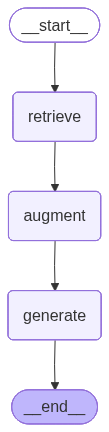

In [16]:
graph = workflow.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

## 6. Invoke the Agent with a Query

Run and Print the retrieved documents to check search accuracy.

In [17]:
output = graph.invoke(
    {"question": "What are Open source models?"}
)

In [21]:
print(output["answer"])

<think>
Okay, let's tackle the user's question: "What are Open source models?" First, I need to look at the provided context to find relevant information. The context is from a guide on large language models, specifically discussing open source models versus proprietary ones.

The user is asking for a definition of open source models. From the context, I recall that the guide mentions open source models are available through communities like Hugging Face, which hosts many models for various tasks. It also talks about the benefits, like the ability to fine-tune them with your own data and host them yourself for privacy and cost management. 

I should structure the answer to first define open source models, then mention where they can be found, their key advantages such as accessibility, customization, and data control. Also, note that while they are improving, they haven't yet matched top proprietary models like GPT-4 in performance. 

Make sure to use examples from the context, like Hu

In [19]:
for message in output["messages"]:
    message.pretty_print()

================================ System Message ================================

You are a helpful AI bot that answers questions based on the provided context.
================================ Human Message =================================

Context: 7
A Compact Guide to Large Language Models
It does currently take a little bit more work to grab an open source model and 
start using it, but progress is moving very quickly to make them more accessible 
to users. On Databricks, for example, we’ve made improvements to open source 
frameworks like MLflow to make it very easy for someone with a bit of Python 
experience to pull any Hugging Face transformer model and use it as a Python 
object. Oftentimes, you can find an open source model that solves your specific 
problem that is orders of magnitude smaller than ChatGPT, allowing you to bring 
the model into your environment and host it yourself. This means that you can 
keep the data in your control for privacy and governance concerns as

## 7. Experiment

Now that you understood how it works, experiment with new things.

- Change the embedding model
- Change the parameters of RecursiveCharacterTextSplitter(chunk_size and chunk_overlap)
- Use your own document
- Add More File Types